## Effective radius

As the REFF_AERO variable showed little growth after Pinatubo, I'll try to see if there is another way to look at it, or if the modes are better to look at seperately.

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob
from scipy import signal

In [2]:
# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 32,Total memory: 35.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41441,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33259,Total threads: 4
Dashboard: http://127.0.0.1:34881/status,Memory: 4.38 GiB
Nanny: tcp://127.0.0.1:36273,


In [3]:
path_atm_22 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251125_pinatubo10Tg22_e01/atm/hist"
ds_22 = xr.open_mfdataset(f"{path_atm_22}/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01.cam.h0.*.nc", combine="by_coords", parallel=True)


In [4]:
path_atm_19_c =  "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20260116_pinatubo10tg_19_c/atm/hist"
ds_19_c = xr.open_mfdataset(f"{path_atm_19_c}/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02.cam.h0.*.nc", combine="by_coords", parallel=True)

In [5]:
path_atm_24 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251129_pinatubo17Tg24_e01/atm/hist"
ds_24 = xr.open_mfdataset(f"{path_atm_24}/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [6]:
path_atm = "/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist"
ds_19 = xr.open_mfdataset(f"{path_atm}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.cam.h0.199*.nc", combine="by_coords", parallel=True)

In [7]:
path_atm_1825 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251204_pinatubo10Tg18_25_e01/atm/hist"
ds_1825 = xr.open_mfdataset(f"{path_atm_1825}/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [8]:
path_atm_1825_17tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251207_pinatubo17Tg18_25_e01/atm/hist"
ds_1825_17tg = xr.open_mfdataset(f"{path_atm_1825_17tg}/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [9]:
path_atm_1tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251210_pinatubo1Tg19_e01/atm/hist"
ds_1tg = xr.open_mfdataset(f"{path_atm_1tg}/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [10]:
path_atm_1pr = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251223_pinatubo10Tg_1pr/atm/hist"
ds_1pr = xr.open_mfdataset(f"{path_atm_1pr}/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr.cam.h0.*.nc", combine="by_coords", parallel=True)

In [11]:
path_atm_60tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20260108_pinatubo60Tg19_e01/atm/hist"
ds_60tg = xr.open_mfdataset(f"{path_atm_60tg}/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19.cam.h0.*.nc", combine="by_coords", parallel=True)

In [12]:
client.close()

In [13]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19['time'].values])
ds_19 = ds_19.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_22['time'].values])
ds_22 = ds_22.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19_c['time'].values])
ds_19_c = ds_19_c.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_24['time'].values])
ds_24 = ds_24.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825['time'].values])
ds_1825 = ds_1825.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825_17tg['time'].values])
ds_1825_17tg = ds_1825_17tg.assign_coords(time=shifted_time)

In [14]:
shifted_time = np.array([shift_one_month_back(t) for t in ds_1tg['time'].values])
ds_1tg = ds_1tg.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1pr['time'].values])
ds_1pr = ds_1pr.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_60tg['time'].values])
ds_60tg = ds_60tg.assign_coords(time=shifted_time)

In [15]:
lat_19 = ds_19["lat"]
weighted_lat_19 = np.cos(np.deg2rad(lat_19))
lat_19_c = ds_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat_19_c))
lat_22 = ds_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat_22))
lat_24 = ds_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat_24))
lat_1825 = ds_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat_1825))
lat_1825_17tg = ds_1825_17tg["lat"]
weighted_lat_1825_17tg = np.cos(np.deg2rad(lat_1825_17tg))
lat_1tg = ds_1tg["lat"]
weighted_lat_1tg = np.cos(np.deg2rad(lat_1tg))
lat_1pr = ds_1pr["lat"]
weighted_lat_1pr = np.cos(np.deg2rad(lat_1pr))
lat_60tg = ds_60tg["lat"]
weighted_lat_60tg = np.cos(np.deg2rad(lat_60tg))

In [16]:
lev_19 = ds_19["lev"]
weighted_lev_19 = np.cos(np.deg2rad(lev_19))
lev_19_c = ds_19_c["lev"]
weighted_lev_19_c = np.cos(np.deg2rad(lev_19_c))
lev_22 = ds_22["lev"]
weighted_lev_22 = np.cos(np.deg2rad(lev_22))
lev_24 = ds_24["lev"]
weighted_lev_24 = np.cos(np.deg2rad(lev_24))
lev_1825 = ds_1825["lev"]
weighted_lev_1825 = np.cos(np.deg2rad(lev_1825))
lev_1825_17tg = ds_1825_17tg["lev"]
weighted_lev_1825_17tg = np.cos(np.deg2rad(lev_1825_17tg))
lev_1tg = ds_1tg["lev"]
weighted_lev_1tg = np.cos(np.deg2rad(lev_1tg))
lev_1pr = ds_1pr["lev"]
weighted_lev_1pr = np.cos(np.deg2rad(lev_1pr))
lev_60tg = ds_60tg["lev"]
weighted_lev_60tg = np.cos(np.deg2rad(lev_60tg))

In [17]:
tropopause_19 = ds_19["TROP_P"].weighted(weighted_lat_19).mean(dim=["lat", "lon"])
p_lev_19 = tropopause_19 * 0.01
tropopause_19_c = ds_19_c["TROP_P"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
p_lev_19_c = tropopause_19_c * 0.01
tropopause_22 = ds_22["TROP_P"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
p_lev_22 = tropopause_22 * 0.01
tropopause_24 = ds_24["TROP_P"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
p_lev_24 = tropopause_24 * 0.01
tropopause_1825 = ds_1825["TROP_P"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
p_lev_1825 = tropopause_1825 * 0.01
tropopause_1825_17tg = ds_1825_17tg["TROP_P"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
p_lev_1825_17tg = tropopause_1825_17tg * 0.01
tropopause_1tg = ds_1tg["TROP_P"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
p_lev_1tg = tropopause_1tg * 0.01
tropopause_1pr = ds_1pr["TROP_P"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
p_lev_1pr = tropopause_1pr * 0.01
tropopause_60tg = ds_60tg["TROP_P"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
p_lev_60tg = tropopause_60tg * 0.01

In [18]:
def compute_SReff(ds, p_lev=None, p_lev_lower=None, p_lev_upper=None,
                  lat_range=None, lon_range=None,
                  weighted_lat=None, weighted_lev=None,
                  cm_to_mym=10000):
    
    da = ds["REFF_AERO"]
    
    if p_lev is not None:
        da = da.sel(lev = p_lev, method="nearest")
    elif p_lev_lower is not None and p_lev_upper is not None:
        da = da.where((da["lev"] >= p_lev_lower) & (da["lev"] <= p_lev_upper))
    elif p_lev_upper is not None:
        da = da.where(da["lev"] < p_lev_upper)
    
    if lat_range:
        da = da.sel(lat=slice(*lat_range))
    if lon_range:
        da = da.sel(lon=slice(*lon_range))
    
    da = da.weighted(weighted_lat).mean(dim=["lat","lon"]) * cm_to_mym
    da = da.weighted(weighted_lev).mean(dim="lev")
    
    return da


<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2985792/1333254674.py:32: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("$\mu$m")


Text(0.5, 1.0, 'Stratospheric R$_{eff}$ (global mean)')

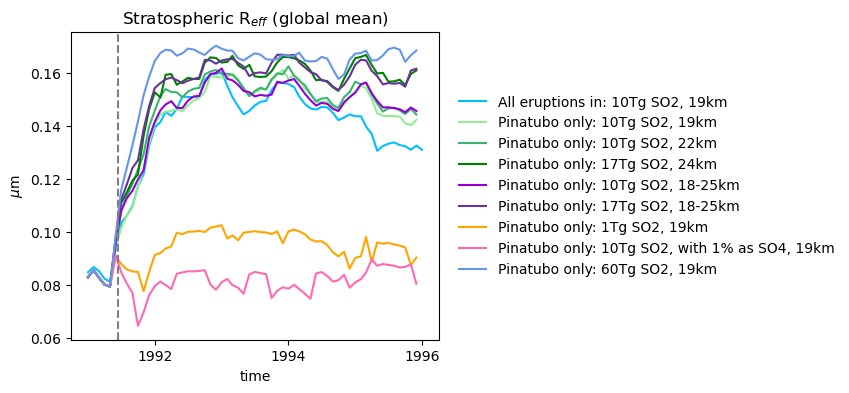

In [44]:
SReff = compute_SReff(ds_19, p_lev_upper = p_lev_19, weighted_lat=weighted_lat_19, weighted_lev=weighted_lev_19)
SReff = SReff.sel(time=slice("1991-01-01", "1996-01-01"))
SReff_19_c = compute_SReff(ds_19_c, p_lev_upper = p_lev_19_c, weighted_lat=weighted_lat_19_c, weighted_lev=weighted_lev_19_c)
SReff_22 = compute_SReff(ds_22, p_lev_upper=p_lev_22, weighted_lat=weighted_lat_22, weighted_lev=weighted_lev_22)
SReff_24 = compute_SReff(ds_24, p_lev_upper=p_lev_24, weighted_lat=weighted_lat_24, weighted_lev=weighted_lev_24)
SReff_1825 = compute_SReff(ds_1825, p_lev_upper=p_lev_1825, weighted_lat=weighted_lat_1825, weighted_lev=weighted_lev_1825)
SReff_1825_17tg = compute_SReff(ds_1825_17tg, p_lev_upper=p_lev_1825_17tg, weighted_lat=weighted_lat_1825_17tg, weighted_lev=weighted_lev_1825_17tg)
SReff_1tg = compute_SReff(ds_1tg, p_lev_upper=p_lev_1tg, weighted_lat=weighted_lat_1tg, weighted_lev=weighted_lev_1tg)
SReff_1pr = compute_SReff(ds_1pr, p_lev_upper=p_lev_1pr, weighted_lat=weighted_lat_1pr, weighted_lev=weighted_lev_1pr)
SReff_60tg = compute_SReff(ds_60tg, p_lev_upper=p_lev_60tg, weighted_lat=weighted_lat_60tg, weighted_lev=weighted_lev_60tg)

fig, ax = plt.subplots(figsize=(7, 4))
SReff.plot(ax=ax, color="deepskyblue", label="All eruptions in: 10Tg SO2, 19km")
SReff_19_c.plot(ax=ax, color="lightgreen", label="Pinatubo only: 10Tg SO2, 19km")
SReff_22.plot(ax=ax, color="mediumseagreen", label="Pinatubo only: 10Tg SO2, 22km")
SReff_24.plot(ax=ax, color="green", label="Pinatubo only: 17Tg SO2, 24km")
SReff_1825.plot(ax=ax, color="darkviolet", label="Pinatubo only: 10Tg SO2, 18-25km")
SReff_1825_17tg.plot(ax=ax, color="rebeccapurple", label="Pinatubo only: 17Tg SO2, 18-25km")
SReff_1tg.plot(ax=ax, color="orange", label="Pinatubo only: 1Tg SO2, 19km")
SReff_1pr.plot(ax=ax, color="hotpink", label="Pinatubo only: 10Tg SO2, with 1% as SO4, 19km")
SReff_60tg.plot(ax=ax, color="cornflowerblue", label="Pinatubo only: 60Tg SO2, 19km")

tline = cftime.DatetimeNoLeap(1991, 6, 15)
ax.axvline(tline, color="gray", linestyle="--")

fig.subplots_adjust(right=0.65)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
ax.set_ylabel("$\mu$m")
ax.set_title("Stratospheric R$_{eff}$ (global mean)")

<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2985792/390019670.py:32: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("$\mu$m")


Text(0.5, 1.0, 'Stratospheric R$_{eff}$ (Tropics)')

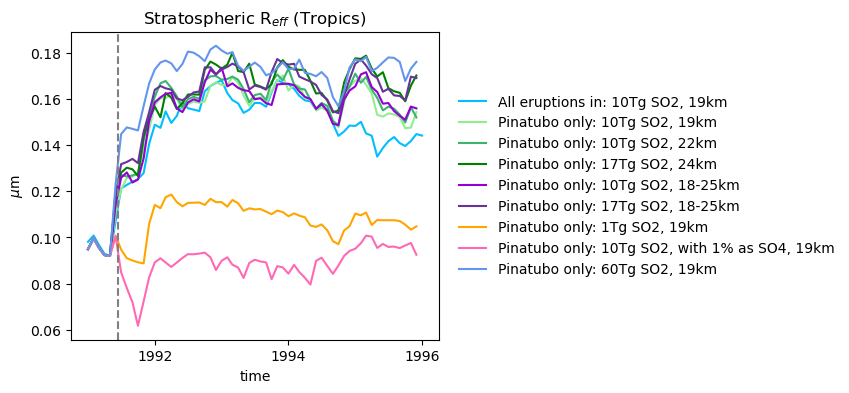

In [45]:
SReff = compute_SReff(ds_19, p_lev_upper = p_lev_19, weighted_lat=weighted_lat_19, weighted_lev=weighted_lev_19, lat_range=(-20,20))
SReff = SReff.sel(time=slice("1991-01-01", "1996-01-01"))
SReff_19_c = compute_SReff(ds_19_c, p_lev_upper = p_lev_19_c, weighted_lat=weighted_lat_19_c, weighted_lev=weighted_lev_19_c, lat_range=(-20,20))
SReff_22 = compute_SReff(ds_22, p_lev_upper=p_lev_22, weighted_lat=weighted_lat_22, weighted_lev=weighted_lev_22, lat_range=(-20,20))
SReff_24 = compute_SReff(ds_24, p_lev_upper=p_lev_24, weighted_lat=weighted_lat_24, weighted_lev=weighted_lev_24, lat_range=(-20,20))
SReff_1825 = compute_SReff(ds_1825, p_lev_upper=p_lev_1825, weighted_lat=weighted_lat_1825, weighted_lev=weighted_lev_1825, lat_range=(-20,20))
SReff_1825_17tg = compute_SReff(ds_1825_17tg, p_lev_upper=p_lev_1825_17tg, weighted_lat=weighted_lat_1825_17tg, weighted_lev=weighted_lev_1825_17tg, lat_range=(-20,20))
SReff_1tg = compute_SReff(ds_1tg, p_lev_upper=p_lev_1tg, weighted_lat=weighted_lat_1tg, weighted_lev=weighted_lev_1tg, lat_range=(-20,20))
SReff_1pr = compute_SReff(ds_1pr, p_lev_upper=p_lev_1pr, weighted_lat=weighted_lat_1pr, weighted_lev=weighted_lev_1pr, lat_range=(-20,20))
SReff_60tg = compute_SReff(ds_60tg, p_lev_upper=p_lev_60tg, weighted_lat=weighted_lat_60tg, weighted_lev=weighted_lev_60tg, lat_range=(-20,20))

fig, ax = plt.subplots(figsize=(7, 4))
SReff.plot(ax=ax, color="deepskyblue", label="All eruptions in: 10Tg SO2, 19km")
SReff_19_c.plot(ax=ax, color="lightgreen", label="Pinatubo only: 10Tg SO2, 19km")
SReff_22.plot(ax=ax, color="mediumseagreen", label="Pinatubo only: 10Tg SO2, 22km")
SReff_24.plot(ax=ax, color="green", label="Pinatubo only: 17Tg SO2, 24km")
SReff_1825.plot(ax=ax, color="darkviolet", label="Pinatubo only: 10Tg SO2, 18-25km")
SReff_1825_17tg.plot(ax=ax, color="rebeccapurple", label="Pinatubo only: 17Tg SO2, 18-25km")
SReff_1tg.plot(ax=ax, color="orange", label="Pinatubo only: 1Tg SO2, 19km")
SReff_1pr.plot(ax=ax, color="hotpink", label="Pinatubo only: 10Tg SO2, with 1% as SO4, 19km")
SReff_60tg.plot(ax=ax, color="cornflowerblue", label="Pinatubo only: 60Tg SO2, 19km")

tline = cftime.DatetimeNoLeap(1991, 6, 15)
ax.axvline(tline, color="gray", linestyle="--")

fig.subplots_adjust(right=0.65)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
ax.set_ylabel("$\mu$m")
ax.set_title("Stratospheric R$_{eff}$ (Tropics)")

<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2985792/3528936901.py:35: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("$\mu$m")


Text(0.5, 1.0, 'Stratospheric R$_{eff}$ (Equator,  lev ~64hPa)')

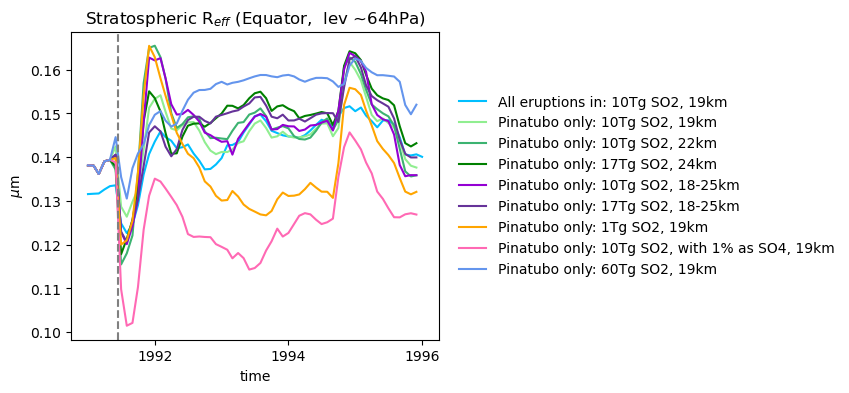

In [46]:
plev = 64
p_lev_l = 50
p_lev_u = 20
SReff = compute_SReff(ds_19, p_lev=plev, weighted_lat=weighted_lat_19, weighted_lev=weighted_lev_19, lat_range=(-5,5))
SReff = SReff.sel(time=slice("1991-01-01", "1996-01-01"))
SReff_19_c = compute_SReff(ds_19_c,  p_lev=plev, weighted_lat=weighted_lat_19_c, weighted_lev=weighted_lev_19_c, lat_range=(-5,5))
SReff_22 = compute_SReff(ds_22,  p_lev=plev, weighted_lat=weighted_lat_22, weighted_lev=weighted_lev_22, lat_range=(-5,5))
SReff_24 = compute_SReff(ds_24, p_lev=plev, weighted_lat=weighted_lat_24, weighted_lev=weighted_lev_24, lat_range=(-5,5))
SReff_1825 = compute_SReff(ds_1825, p_lev=plev, weighted_lat=weighted_lat_1825, weighted_lev=weighted_lev_1825, lat_range=(-5,5))
SReff_1825_17tg = compute_SReff(ds_1825_17tg, p_lev=plev,weighted_lat=weighted_lat_1825_17tg, weighted_lev=weighted_lev_1825_17tg, lat_range=(-5,5))
SReff_1tg = compute_SReff(ds_1tg, p_lev=plev, weighted_lat=weighted_lat_1tg, weighted_lev=weighted_lev_1tg, lat_range=(-5,5))
SReff_1pr = compute_SReff(ds_1pr, p_lev=plev, weighted_lat=weighted_lat_1pr, weighted_lev=weighted_lev_1pr, lat_range=(-5,5))
SReff_60tg = compute_SReff(ds_60tg, p_lev=plev, weighted_lat=weighted_lat_60tg, weighted_lev=weighted_lev_60tg, lat_range=(-5,5))

fig, ax = plt.subplots(figsize=(7, 4))
SReff.plot(ax=ax, color="deepskyblue", label="All eruptions in: 10Tg SO2, 19km")
SReff_19_c.plot(ax=ax, color="lightgreen", label="Pinatubo only: 10Tg SO2, 19km")
SReff_22.plot(ax=ax, color="mediumseagreen", label="Pinatubo only: 10Tg SO2, 22km")
SReff_24.plot(ax=ax, color="green", label="Pinatubo only: 17Tg SO2, 24km")
SReff_1825.plot(ax=ax, color="darkviolet", label="Pinatubo only: 10Tg SO2, 18-25km")
SReff_1825_17tg.plot(ax=ax, color="rebeccapurple", label="Pinatubo only: 17Tg SO2, 18-25km")
SReff_1tg.plot(ax=ax, color="orange", label="Pinatubo only: 1Tg SO2, 19km")
SReff_1pr.plot(ax=ax, color="hotpink", label="Pinatubo only: 10Tg SO2, with 1% as SO4, 19km")
SReff_60tg.plot(ax=ax, color="cornflowerblue", label="Pinatubo only: 60Tg SO2, 19km")

tline = cftime.DatetimeNoLeap(1991, 6, 15)
ax.axvline(tline, color="gray", linestyle="--")

fig.subplots_adjust(right=0.65)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
ax.set_ylabel("$\mu$m")
ax.set_title("Stratospheric R$_{eff}$ (Equator,  lev ~64hPa)")


<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2985792/1297253290.py:36: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("$\mu$m")


Text(0.5, 1.0, 'Stratospheric R$_{eff}$ (Laramie, lev ~64hPa)')

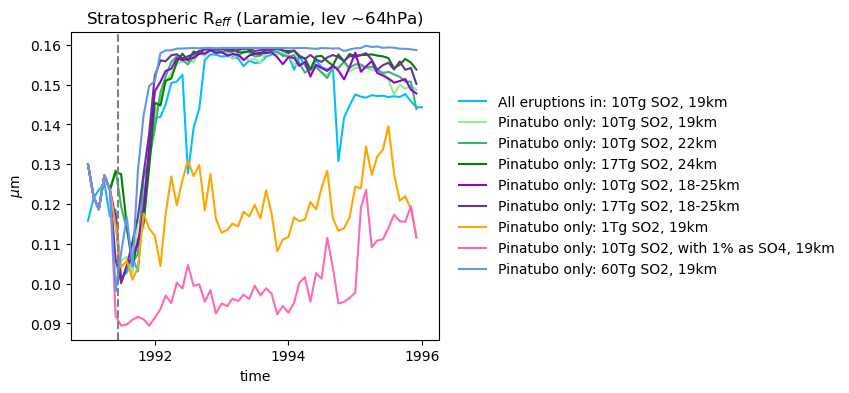

In [47]:
cm_to_mym = 10000
p_lev_l = 130
p_lev_u = 10
plev = 64
SReff = compute_SReff(ds_19, p_lev=plev, weighted_lat=weighted_lat_19, weighted_lev=weighted_lev_19, lat_range=(40,43), lon_range=(105, 106.5))
SReff = SReff.sel(time=slice("1991-01-01", "1996-01-01"))
SReff_19_c = compute_SReff(ds_19_c,  p_lev=plev, weighted_lat=weighted_lat_19_c, weighted_lev=weighted_lev_19_c, lat_range=(40,43), lon_range=(105, 106.5))
SReff_22 = compute_SReff(ds_22,  p_lev=plev, weighted_lat=weighted_lat_22, weighted_lev=weighted_lev_22, lat_range=(40,43), lon_range=(105, 106.5))
SReff_24 = compute_SReff(ds_24, p_lev=plev, weighted_lat=weighted_lat_24, weighted_lev=weighted_lev_24, lat_range=(40,43), lon_range=(105, 106.5))
SReff_1825 = compute_SReff(ds_1825,  p_lev=plev, weighted_lat=weighted_lat_1825, weighted_lev=weighted_lev_1825, lat_range=(40,43), lon_range=(105, 106.5))
SReff_1825_17tg = compute_SReff(ds_1825_17tg,  p_lev=plev, weighted_lat=weighted_lat_1825_17tg, weighted_lev=weighted_lev_1825_17tg, lat_range=(40,43), lon_range=(105, 106.5))
SReff_1tg = compute_SReff(ds_1tg,  p_lev=plev, weighted_lat=weighted_lat_1tg, weighted_lev=weighted_lev_1tg, lat_range=(40,43), lon_range=(105, 106.5))
SReff_1pr = compute_SReff(ds_1pr,  p_lev=plev, weighted_lat=weighted_lat_1pr, weighted_lev=weighted_lev_1pr, lat_range=(40,43), lon_range=(105, 106.5))
SReff_60tg = compute_SReff(ds_60tg,  p_lev=plev, weighted_lat=weighted_lat_60tg, weighted_lev=weighted_lev_60tg, lat_range=(40,43), lon_range=(105, 106.5))

fig, ax = plt.subplots(figsize=(7, 4))
SReff.plot(ax=ax, color="deepskyblue", label="All eruptions in: 10Tg SO2, 19km")
SReff_19_c.plot(ax=ax, color="lightgreen", label="Pinatubo only: 10Tg SO2, 19km")
SReff_22.plot(ax=ax, color="mediumseagreen", label="Pinatubo only: 10Tg SO2, 22km")
SReff_24.plot(ax=ax, color="green", label="Pinatubo only: 17Tg SO2, 24km")
SReff_1825.plot(ax=ax, color="darkviolet", label="Pinatubo only: 10Tg SO2, 18-25km")
SReff_1825_17tg.plot(ax=ax, color="rebeccapurple", label="Pinatubo only: 17Tg SO2, 18-25km")
SReff_1tg.plot(ax=ax, color="orange", label="Pinatubo only: 1Tg SO2, 19km")
SReff_1pr.plot(ax=ax, color="hotpink", label="Pinatubo only: 10Tg SO2, with 1% as SO4, 19km")
SReff_60tg.plot(ax=ax, color="cornflowerblue", label="Pinatubo only: 60Tg SO2, 19km")

tline = cftime.DatetimeNoLeap(1991, 6, 15)
ax.axvline(tline, color="gray", linestyle="--")

fig.subplots_adjust(right=0.65)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
ax.set_ylabel("$\mu$m")
ax.set_title("Stratospheric R$_{eff}$ (Laramie, lev ~64hPa)")

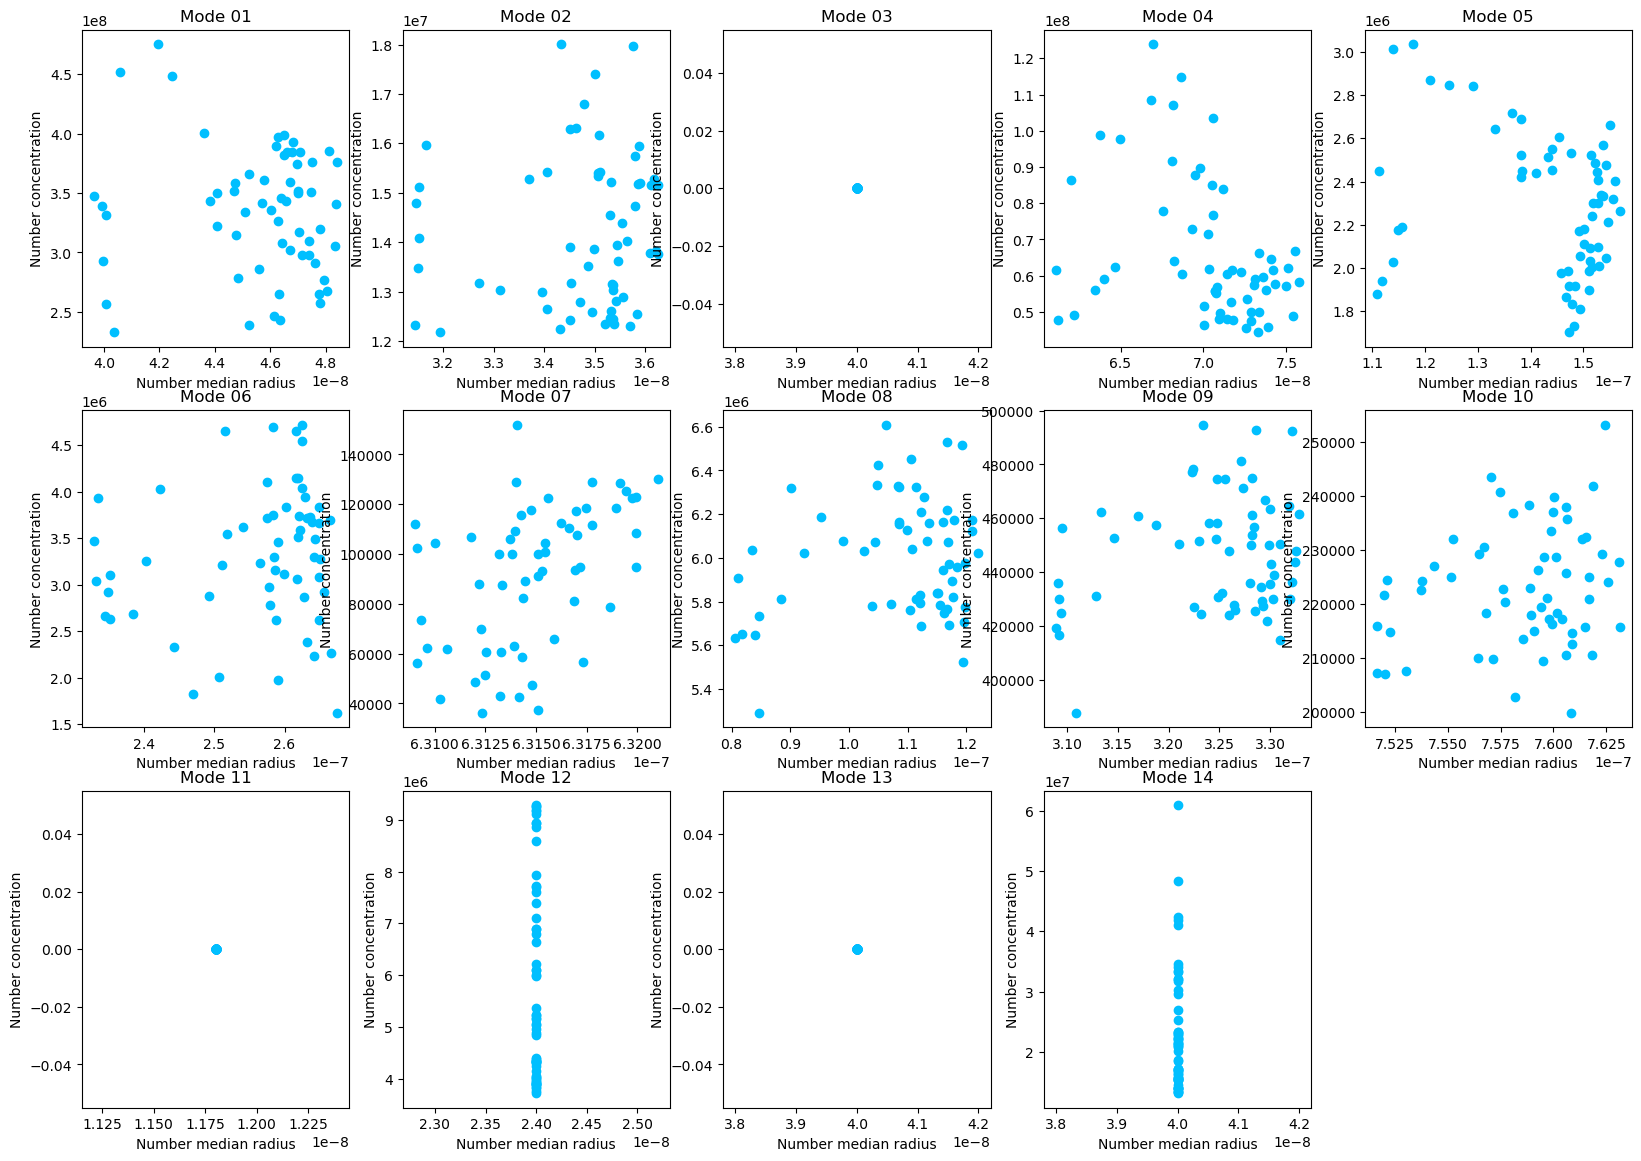

In [23]:
# vars to use: NMR, SIGMA, NCONC, VCONC, NNAT_
mode_list = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12", "13", "14"]

fig, axes = plt.subplots(3, 5, figsize=(20, 14), sharex=False, sharey=False)
axes = axes.flatten() 
for i, mode in enumerate(mode_list):
    nmr_var = f"NMR{mode}"
    nconc_var = f"NCONC{mode}"
    
    nmr = ds_1pr[nmr_var].weighted(weighted_lat_1pr).mean(dim=["lat","lon","lev"])
    nconc = ds_1pr[nconc_var].weighted(weighted_lat_1pr).mean(dim=["lat","lon","lev"])
    
    axes[i].scatter(nmr, nconc, color="deepskyblue")
    axes[i].set_xlabel("Number median radius")
    axes[i].set_ylabel("Number concentration")
    axes[i].set_title(f"Mode {mode}")

for j in range(i+1, 3*5):
    fig.delaxes(axes[j])

plt.show()

## With Observations

In [24]:
path_obs = "/nird/datapeak/NS1004K/elihho/obs_pinatubo/dataset/Observation"
sageii_tropreff = pd.read_csv(f"{path_obs}/sageii_tropical_reff.txt", delim_whitespace=True, header=0,  index_col=0)
start = pd.Timestamp("1991-01-01")
months_sageii = [int(c) for c in sageii_tropreff.columns]
dates_sageii = [start + pd.DateOffset(months=m) for m in months_sageii]
sageii_tropreff.columns = dates_sageii

/tmp/ipykernel_2985792/1079825040.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  sageii_tropreff = pd.read_csv(f"{path_obs}/sageii_tropical_reff.txt", delim_whitespace=True, header=0,  index_col=0)


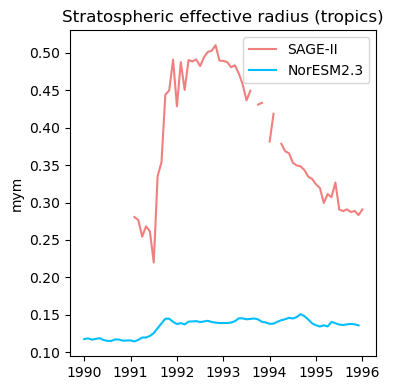

In [25]:
strat_reff_sageii = sageii_tropreff.loc["Strat_mean_sad_weighted"].astype(float)
cm_to_mym = 10000

SReff = ds_19["REFF_AERO"].where(ds_19["REFF_AERO"]["lev"] <= p_lev_19)
SReff_trop = SReff.sel(lat = slice(-20,20))
SReff_trop = SReff_trop.weighted(weighted_lat_19).mean(dim=["lat", "lon", "lev"]) * cm_to_mym
SReff_trop = SReff_trop.sel(time=slice("1990-01-01", "1995-12-31"))

obs_time_sageii = np.array([t.year + (t.month-1)/12 for t in strat_reff_sageii.index])
time_years = np.array([t.year + (t.month-1)/12 for t in SReff_trop.time.values])

plt.figure(figsize=(4, 4))
plt.plot(obs_time_sageii, strat_reff_sageii, color = "lightcoral", label = "SAGE-II")
plt.plot(time_years, SReff_trop, color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("mym")
plt.title("Stratospheric effective radius (tropics)")
plt.legend()
plt.tight_layout()

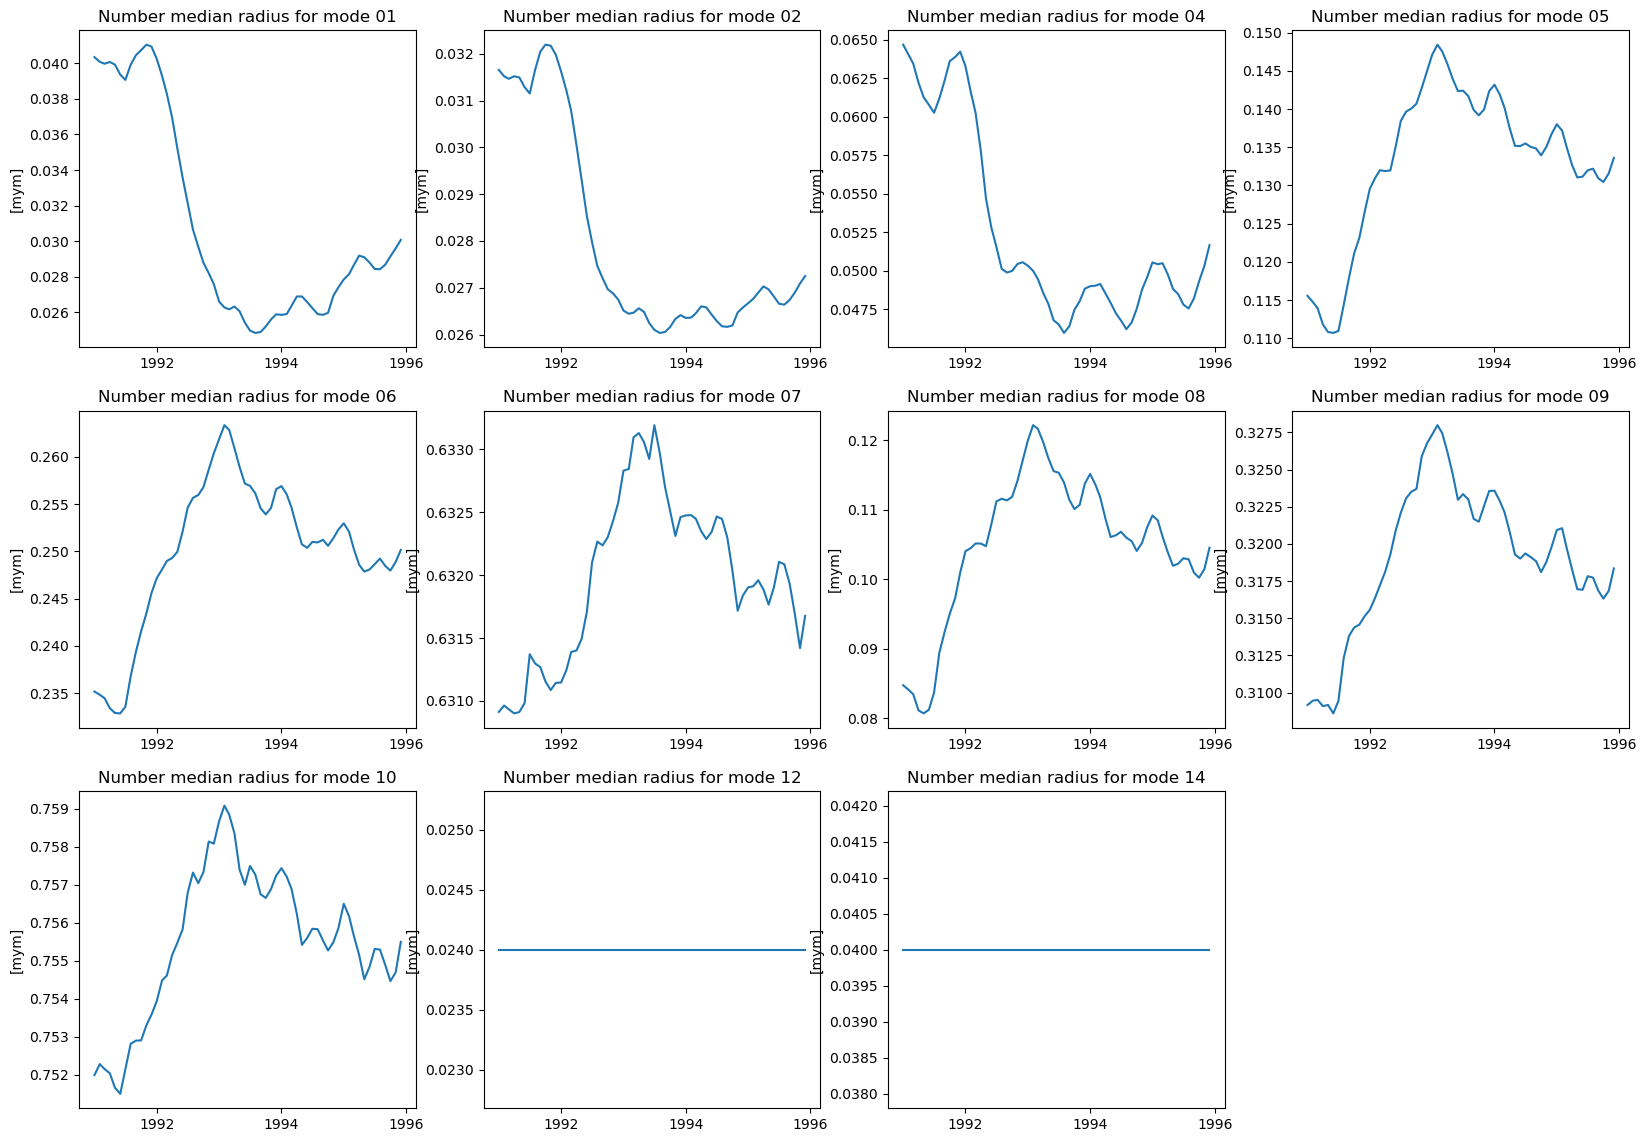

In [26]:
modes = ["01", "02", "04", "05", "06", "07", "08", "09", "10", "12", "14"]
m_to_mym = cm_to_mym*100
fig, axes = plt.subplots(3, 4, figsize=(20, 14), sharex=False, sharey=False)
axes = axes.flatten() 
for i, m in enumerate(modes):
    nmr = ds_60tg[f"NMR{m}"].weighted(weighted_lat_60tg).mean(dim=["lat","lon","lev"])*m_to_mym
    axes[i].plot(nmr.time, nmr)
    axes[i].set_ylabel("[mym]")
    axes[i].set_title(f"Number median radius for mode {m}")

for j in range(i+1, 3*4):
    fig.delaxes(axes[j])

plt.show()

In [27]:
ds_19_c["NMR01"]

<xarray.DataArray 'NMR01' (time: 60, lev: 32, lat: 192, lon: 288)> Size: 425MB
dask.array<concatenate, shape=(60, 32, 192, 288), dtype=float32, chunksize=(1, 32, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * time     (time) object 480B 1991-01-01 00:00:00 ... 1995-12-01 00:00:00
Attributes:
    mdims:         1
    units:         m
    long_name:     number median radius mode 01
    cell_methods:  time: mean

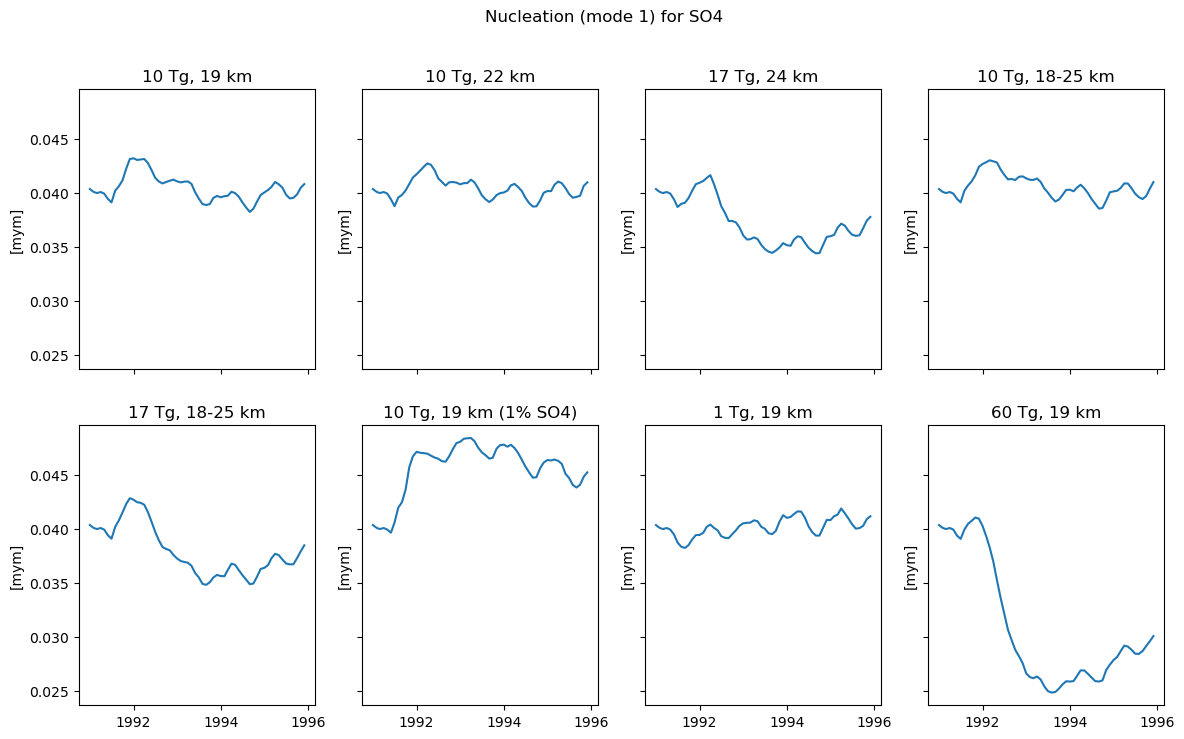

In [28]:
so4_modes = ["01", "05"]
ds = [ds_19_c, ds_22, ds_24, ds_1825, ds_1825_17tg, ds_1pr, ds_1tg, ds_60tg]

titles = ["10 Tg, 19 km", 
          "10 Tg, 22 km", 
          "17 Tg, 24 km", 
          "10 Tg, 18-25 km", 
          "17 Tg, 18-25 km", 
          "10 Tg, 19 km (1% SO4)", 
          "1 Tg, 19 km", 
          "60 Tg, 19 km"]

fig, axs = plt.subplots(2, 4, figsize=(14, 8), sharex=True, sharey=True)

for ax, ds, title in zip(axs.flat, ds, titles):
    nmr = ds[f"NMR01"].weighted(weighted_lat_19).mean(dim=["lat","lon","lev"])*m_to_mym
    ax=ax
    ax.plot(nmr.time, nmr)
    ax.set_ylabel("[mym]")
    ax.set_title(title)

plt.suptitle("Nucleation (mode 1) for SO4")
plt.show()

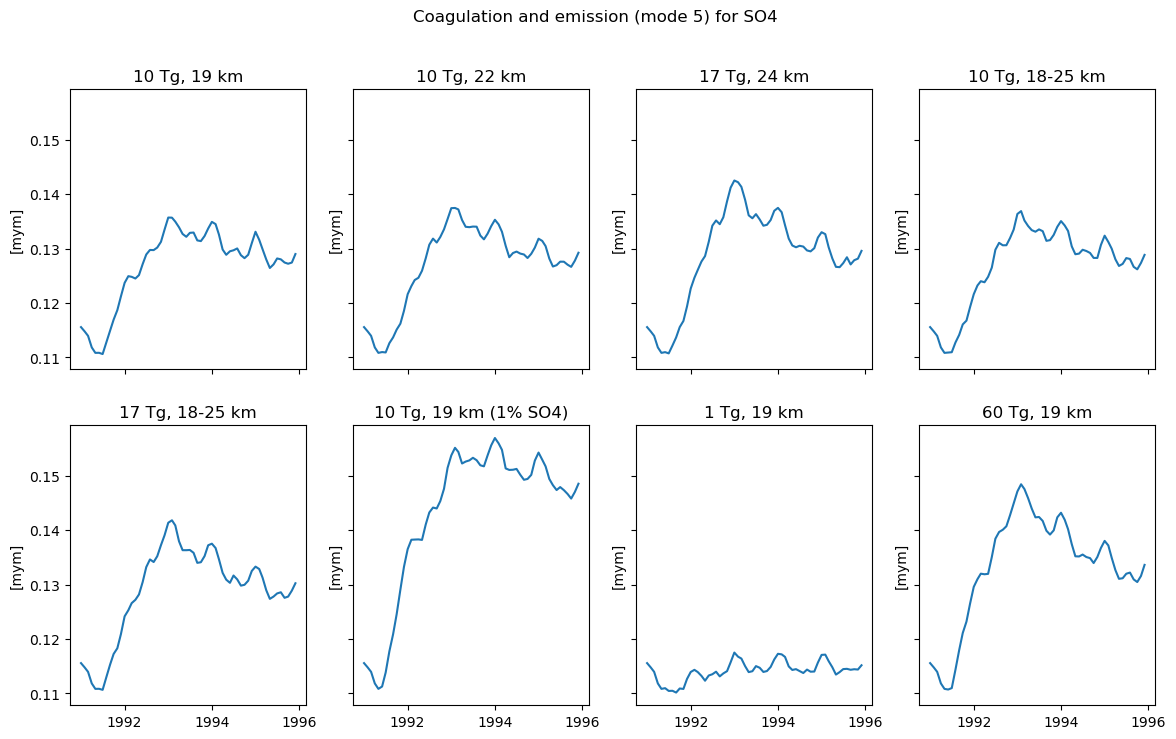

In [29]:
so4_modes = ["01", "05"]
ds = [ds_19_c, ds_22, ds_24, ds_1825, ds_1825_17tg, ds_1pr, ds_1tg, ds_60tg]

titles = ["10 Tg, 19 km", 
          "10 Tg, 22 km", 
          "17 Tg, 24 km", 
          "10 Tg, 18-25 km", 
          "17 Tg, 18-25 km", 
          "10 Tg, 19 km (1% SO4)", 
          "1 Tg, 19 km", 
          "60 Tg, 19 km"]

fig, axs = plt.subplots(2, 4, figsize=(14, 8), sharex=True, sharey=True)

for ax, ds, title in zip(axs.flat, ds, titles):
    nmr = ds[f"NMR05"].weighted(weighted_lat_19).mean(dim=["lat","lon","lev"])*m_to_mym
    ax=ax
    ax.plot(nmr.time, nmr)
    ax.set_ylabel("[mym]")
    ax.set_title(title)

plt.suptitle("Coagulation and emission (mode 5) for SO4")
plt.show()

In [55]:
path_daily = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20260120_pinatubo10Tg19_daily_branch/atm/hist"
ds_daily = xr.open_dataset(f'{path_daily}/NHIST_tropstratchem_f09_tn14_20260120_Pinatubo10Tg19_daily_branch.cam.h0.1991-06-02-00000.nc')

In [56]:
lat_daily = ds_daily["lat"]
weighted_lat_daily = np.cos(np.deg2rad(lat_daily))
tropopause_daily = ds_daily["TROP_P"].weighted(weighted_lat_daily).mean(dim=["lat", "lon"])
p_lev_daily = tropopause_daily * 0.01

In [59]:
Reff_daily = ds_daily["REFF_AERO"].where(ds_daily["REFF_AERO"]["lev"] >= p_lev_daily)
Reff_daily = Reff_daily.weighted(weighted_lat_daily).mean(dim=["lev", "lat", "lon"]) * cm_to_mym

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2985792/2864911637.py:2: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$m")


Text(0.5, 1.0, 'Daily R$_{eff}$ in June (eruption date 15.06.1991)')

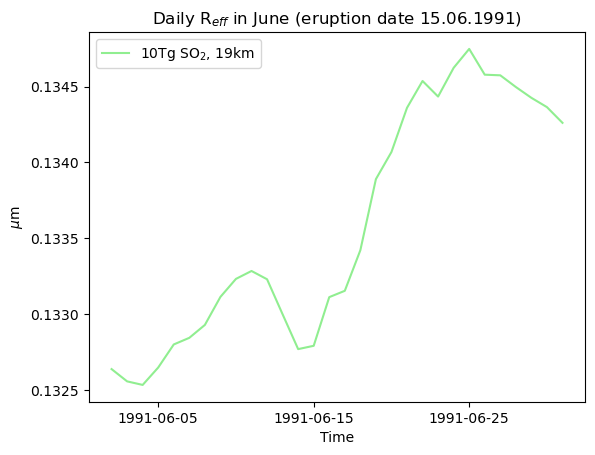

In [60]:
plt.plot(Reff_daily.time, Reff_daily, color="lightgreen", label="10Tg SO$_2$, 19km")
plt.ylabel("$\mu$m")
plt.xlabel("Time")
plt.legend()
plt.title("Daily R$_{eff}$ in June (eruption date 15.06.1991)")

In [65]:
import calculate3dpressure
import interp1d
import interp3dplev19 as interp

In [ ]:
reff = ds_daily["REFF_AERO"]

out = []

for t in range(ds_daily.sizes["time"]):
    reff_t = reff.isel(time=t)
    ps_t   = ds_daily["PS"].isel(time=t)

    reff_plev19 = interp.interp3dplev19(
        field=reff_t,
        ps=ps_t,
        p0=ds_daily["P0"],
        hyam=ds_daily["hyam"],
        hybm=ds_daily["hybm"]
        )

    out.append(reff_plev19)

In [70]:
reff_t.shape

(32, 192, 288)